In [7]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, r2_score

--- Initial Missing Value Count ---
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

--- Data after cleaning and feature combination ---
                                 Name    Year Duration  \
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min   
3                             #Yaaram  (2019)  110 min   
5                ...Aur Pyaar Ho Gaya  (1997)  147 min   
6                           ...Yahaan  (2005)  142 min   
8                  ?: A Question Mark  (2012)   82 min   

                       Genre  Rating  Votes        Director          Actor 1  \
1                      Drama     7.0      8   Gaurav Bakshi     Rasika Dugal   
3            Comedy, Romance     4.4     35      Ovais Khan          Prateik   
5     Comedy, Drama, Musical     4.7    827    Rahul Rawail       Bobby Deol   
6        Drama, Romance, War     7.4  1,086  Shoojit Sircar

C:\Users\sahap\AppData\Local\Temp\ipykernel_11852\3759910282.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  movie_df['Genre'].fillna('Unknown', inplace=True)
C:\Users\sahap\AppData\Local\Temp\ipykernel_11852\3759910282.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 


--- Model Evaluation ---
Mean Squared Error (MSE): 3.8454
Root Mean Squared Error (RMSE): 1.9610
R-squared (R2 Score): -1.0684


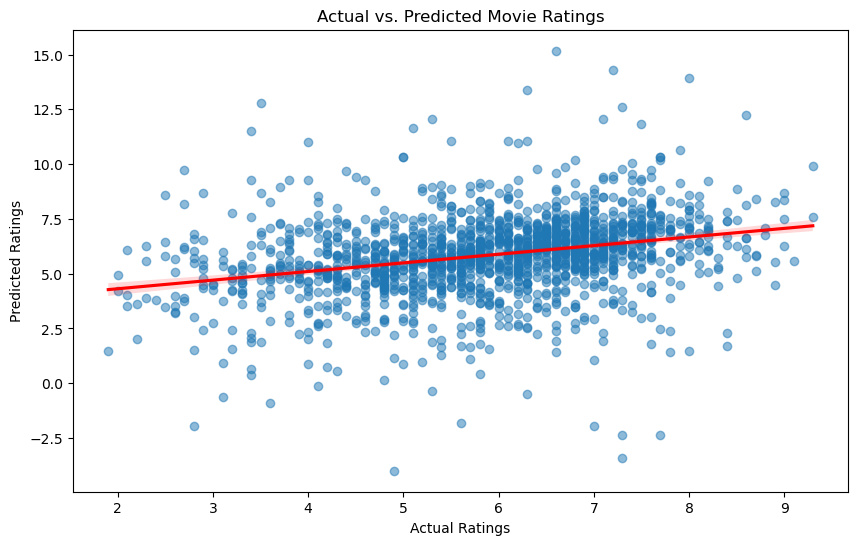

In [8]:
# load ataset
movie_df = pd.read_csv('IMDb Movies India.csv', encoding='latin1')

# Make sure the file was loaded
if not movie_df.empty:
    
    # Check for missing data
    
    print("--- Missing Value ---")
    print(movie_df.isnull().sum())
    
    # Drop rows
    movie_df.dropna(subset=['Rating'], inplace=True)

    # Fill the gaps with 'Unknown'
    movie_df['Actor 1'].fillna('Unknown', inplace=True)
    movie_df['Actor 2'].fillna('Unknown', inplace=True)
    movie_df['Actor 3'].fillna('Unknown', inplace=True)
    movie_df['Genre'].fillna('Unknown', inplace=True)
    movie_df['Director'].fillna('Unknown', inplace=True)

    # # Combine genre/director/actors into one big feature string
    movie_df['features'] = movie_df['Genre'] + ' ' + movie_df['Director'] + ' ' + movie_df['Actor 1'] + ' ' + movie_df['Actor 2'] + ' ' + movie_df['Actor 3']

    # Check on the new column
    print("\n--- Data after cleaning ---")
    print(movie_df.head())

    # Vectorize the text and 5k features should be enough
    vectorizer = TfidfVectorizer(max_features=5000)

    # # X is our text features and  y is the rating to predict
    X = vectorizer.fit_transform(movie_df['features'])
    y = movie_df['Rating']

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # A simple linearRegression model
    model = LinearRegression()
    
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = model.predict(X_test)

    # Calculate Regression Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Print scores
    print(f"\n--- model evaluation ---")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2 Score): {r2:.4f}")

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.regplot(x = y_test, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.xlabel('Actual Ratings')
    plt.ylabel('Predicted Ratings')
    plt.title('Actual vs. Predicted Movie Ratings')
    plt.show()